In [108]:
# 1. Настройка автоперезагрузки модулей (удобно при разработке)
%load_ext autoreload
%autoreload 2

# 2. Импорт конфигов
import config as cnfg
import config_paths as cnfg_p

# 3. Проверка и создание папок (если их нет)
# При первом запуске он создаст папки data/raw, data/processed и т.д.
cnfg_p.init_structure()

# 4. Библиотечные импорты
import matplotlib.pyplot as plt

# 5. Импорт ваших расчетных модулей
from scripts import generate_data as gdt
from scripts import data_manager as dm
from scripts import plot_manager as pm
# from scripts import pressure_predictor as ppm
from scripts.independent_linear_predictor import pressure_predictor_lite as prm
from scripts.coupled_linear_predictor import pressure_predictor_coupled as coprm
from scripts.coupled_linear_predictor import coupled_optimizer as copt

# from scripts.independent_linear_predictor import model_optimizator as opt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
--- Проверка структуры проекта ---
[OK] data\raw
[OK] data\processed
[OK] data\config
[OK] gui
----------------------------------



In [ ]:
# df_avg_logs, df_avg_registry, df_reference_setpoint = gdt.start_generate_data()
df_avg_logs, df_avg_registry, df_reference_setpoint = gdt.load_processed_data()

Экстракция завершена. Обработано 3889 циклов.
Экстракция завершена. Обработано 3889 циклов.
Загрузка: ТК.20-500.895.1-7.4. ред.0 (настроечные параметры дезоксидации).csv
Загружена техкарта
[Classify] Создана колонка 'Dia_Shell' на основе 'LD11C1\Process Data.BarDiameter (Диаметр заготовки)'
[Classify] Создана колонка 'L_Shell' на основе 'CtpOut002_Shell_length (Длина гильзы)'
Классификация циклов завершена
Усреднение циклов завершено
Расчет целевых значений по тех карте завершен


In [123]:
cnfg_params_tank, flat_params_tank = dm.load_config(cnfg_p.DEFAULT_MODEL_PARAMS_TANK_FILE)
cnfg_params_pipe, flat_params_pipe = dm.load_config(cnfg_p.DEFAULT_MODEL_PARAMS_PIPE_FILE)

In [124]:
cycle_ids = [
    "AVG_D_273_L_11300",
    "AVG_D_182_L_9000",
    "AVG_D_182_L_8000",
    "AVG_D_182_L_7000",
    "AVG_D_182_L_6000",
]

df_avg_logs, df_avg_registry = dm.remove_cycles_from_data(df_avg_logs, df_avg_registry, cycle_ids, col_cycle='cycle_id')

In [125]:
# dm.show_columns_list(df_avg_registry)
dm.show_columns_list(df_avg_logs)
# dm.show_columns_list(df_reference_setpoint)


--- Список полей ---
"Dia_Shell",
"L_Shell",
"t_relative",
"Curve_cycle_1",
"Curve_cycle_2",
"Curve_cycle_3",
"Curve_cycle_4",
"Curve_cycle_5",
"Curve_cycle_6",
"Curve_cycle_7",
"Curve_cycle_8",
"Curve_cycle_9",
"DB_Internal\Cmd_PUY1019 - давление в спирали",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_median",
"IBA_DB\PT1009 Актуальное давление в баке P1 (бар)_std",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)_median",
"IBA_DB\PT1010 Актуальное давление в спирали (бар)_std",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)_median",
"IBA_DB\PT1014 Актуальное давление в трубе (бар)_std",
"LD31W.Spray.PT1014 - давление трубе",
"LD31W.VALVE 1007 - клапан бака, бар",
"LD31W.VALVE 1007 - клапан бака, бар_median",
"LD31W.VALVE 1007 - клапан бака, бар_std",
"LD31W.VALVE 1008 - клапан трубы, бар",
"LD31W.VALVE 1008 - клапан т

*Алгоритм оптимизации 

In [126]:
df_logs, df_registry = coprm.apply_coupled_model(
    df_avg_logs, 
    df_avg_registry, 
    cnfg.CONFIG_PREDICTOR_TANK, 
    cnfg.CONFIG_PREDICTOR_PIPE, 
    flat_params_tank, 
    flat_params_pipe
    )

In [127]:
best_config_tank, best_config_pipe = copt.run_universal_optimizer(
        df_avg_logs, 
        df_avg_registry, 
        cnfg_params_tank,
        cnfg_params_pipe, 
        cnfg.CONFIG_PREDICTOR_TANK, 
        cnfg.CONFIG_PREDICTOR_PIPE, 
        param_keys=None)

 ЗАПУСК ГЛОБАЛЬНОЙ ОПТИМИЗАЦИИ (DIFFERENTIAL EVOLUTION)
Количество анализируемых циклов: 9
Размерность задачи (параметров): 10
Размер популяции (агентов):     100
Начальная суммарная ошибка MAE:  0.17655 бар
Оптимизируемые параметры:
  - [tank] dead_time    | Текущее: 0.54   | Ограничения: [0.0, 1.0]
  - [tank] k_gain       | Текущее: 0.085  | Ограничения: [0.01, 0.3]
  - [tank] b_gain       | Текущее: 0.015  | Ограничения: [0.001, 0.1]
  - [tank] damping      | Текущее: 1.5    | Ограничения: [0.1, 5.0]
  - [tank] sigma_out    | Текущее: 0.15   | Ограничения: [0.0, 1.5]
  - [pipe] dead_time    | Текущее: 0.62   | Ограничения: [0.0, 1.0]
  - [pipe] k_gain       | Текущее: 0.075  | Ограничения: [0.01, 0.3]
  - [pipe] b_gain       | Текущее: 0.01   | Ограничения: [0.001, 0.1]
  - [pipe] damping      | Текущее: 0.9    | Ограничения: [0.1, 5.0]
  - [pipe] sigma_in     | Текущее: 0.35   | Ограничения: [0.0, 1.5]
--------------------------------------------------------------------------------

KeyboardInterrupt: 

In [128]:
dm.save_config(best_config_tank, cnfg_p.CONFIG_DIR / "Optimal_model_params_tank.json")
dm.save_config(best_config_pipe, cnfg_p.CONFIG_DIR / "Optimal_model_params_pipe.json")

Конфигурация сохранена: Optimal_model_params_tank.json
Конфигурация сохранена: Optimal_model_params_pipe.json


In [129]:
# params_to_tune = ["dead_time", "k_gain", "b_gain", "damping"]

# best_params, raw_result = opt.run_universal_optimizer(
#     df_avg_logs, 
#     df_avg_registry, 
#     cnfg_params,
#     # cnfg.CONFIG_PREDICTOR_TANK, 
#     cnfg.CONFIG_PREDICTOR_PIPE, 
#     params_to_tune
# )

# best_params теперь содержит что-то вроде:
# {'dead_time': 0.12, 'k_gain': 0.035, 'b_gain': 0.015, 'damping': 0.42}

In [130]:
# dm.save_config(best_params, cnfg_p.CONFIG_DIR / "Optimal_model_params_pipe_4_7.json")

In [131]:
best_flat_tank = dm.get_flat_params(best_config_tank)
best_flat_pipe = dm.get_flat_params(best_config_pipe)

In [132]:
df_avg_logs, df_avg_registry = coprm.apply_coupled_model(
    df_avg_logs, 
    df_avg_registry, 
    cnfg.CONFIG_PREDICTOR_TANK, 
    cnfg.CONFIG_PREDICTOR_PIPE, 
    best_flat_tank, 
    best_flat_pipe
    )

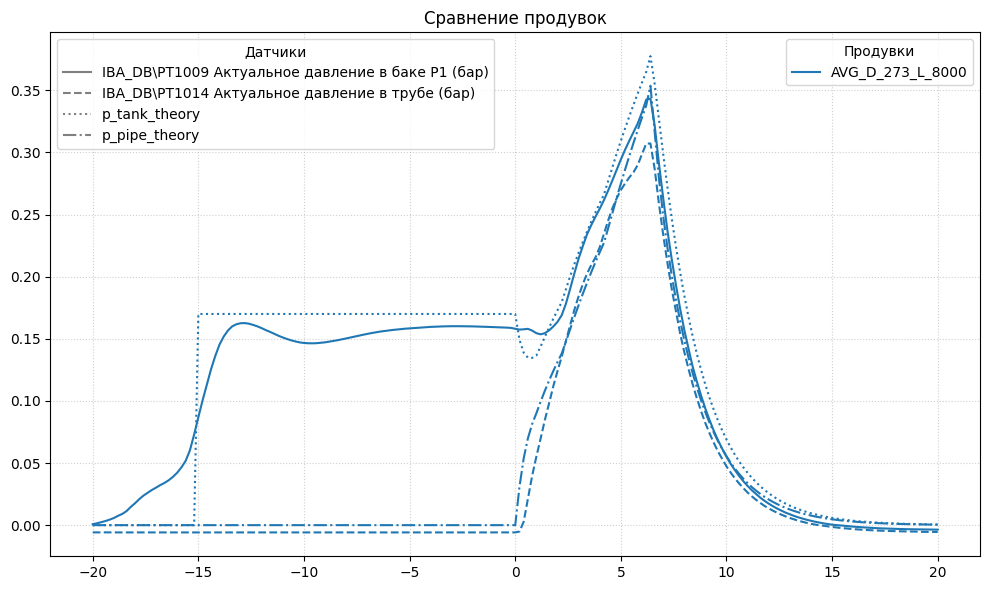

In [133]:
%matplotlib inline
# %matplotlib widget
identifiers = [
    # "AVG_D_182_L_6000",
    # "AVG_D_182_L_7000",
    # "AVG_D_182_L_9000",
    # "AVG_D_182_L_10000",
    "AVG_D_273_L_8000", 
    # "AVG_D_273_L_10000", 
    # "AVG_D_273_L_11300",
    # "AVG_D_334_L_7000",
    # "AVG_D_334_L_8000"
    ]
sensors = [
    "IBA_DB\PT1009 Актуальное давление в баке P1 (бар)",
    # "LD31W.VALVE 1007 - клапан бака, бар",
    "IBA_DB\PT1014 Актуальное давление в трубе (бар)",

    # "LD31W.VALVE 1007 - клапан бака, бар_median",   
    # "LD31W.VALVE 1008 - клапан трубы, бар"
    'p_tank_theory',
    # "p_pipe_target",
    # 'p_residual_error',
    # 'p_tank_target',
    'p_pipe_theory',
    # "p_tank_target_rounded",
    # "p_pipe_target_rounded",

    # "p_cycle_mae"
    # "LD31W.Weigh P1 - вес в баке"
 ]
pm.plot_cycles(df_avg_logs, df_avg_registry, identifiers, sensors)
# plt.xlim(-18, 20)
# plt.xlim(-18, 20)
# plt.ylim(-0.05, 0.6)
# plt.plot(result_df['t_relative'], result_df['p_tank_theory'], label='Модельное давление в баке', color='orange')

In [134]:
dm.get_summary(df_avg_registry, only_labeled=False)

,cycle_id,duration,Dia_Shell,L_Shell,n_samples
0,AVG_D_182_L_10000,7.426748,182,10000,329
1,AVG_D_273_L_10000,7.730753,273,10000,465
2,AVG_D_273_L_6000,6.725581,273,6000,43
3,AVG_D_273_L_7000,6.966296,273,7000,629
4,AVG_D_273_L_8000,7.227551,273,8000,196
5,AVG_D_273_L_9000,7.468740,273,9000,643
6,AVG_D_334_L_11300,7.829677,334,11300,155
7,AVG_D_334_L_7000,6.920988,334,7000,162
8,AVG_D_334_L_8000,7.325301,334,8000,249
